# Tutorial: Markov chain particle deposition in mouse airway trees

This notebook demonstrates how to use the Markov chain deposition model to simulate and compare particle deposition across different impaction formula variants.

## Requirements

- LAPDMouse dataset (download from https://cebs-ext.niehs.nih.gov/cahs/report/lapd/web-download-links)
- Python dependencies: see `requirements.txt`

## Contents

1. [Setup and data loading](#1-Setup-and-data-loading)
2. [Run the deposition model on a single mouse](#2-Run-the-deposition-model-on-a-single-mouse)
3. [Compare impaction models](#3-Compare-impaction-models)
4. [Aggregate results across multiple mice](#4-Aggregate-results-across-multiple-mice)
5. [Compare with morphometric references](#5-Compare-with-morphometric-references)


## 1. Setup and data loading

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add scripts directory to path
sys.path.insert(0, str(Path("../scripts")))

from model_deposition import (
    load_trees,
    add_child,
    propagate_flow,
    compute_probabilities,
    propagate_probabilities,
    compute_generation,
)


In [2]:
# Set this to the path of your local LAPDMouse dataset
DATA_PATH = Path("/dev_sda/mpuig/lapdMouseDB")

# Physical simulation parameters
Q_INTAKE = 2.08e-6       # Intake flow rate in m³/s
PARTICLE_SIZE = 1e-6     # Particle diameter in meters (1 µm)
IMPACTION_MODEL = "chan_lipp"  # Options: "chan_lipp", "yeh_schum", "zhang"


## 2. Run the deposition model on a single mouse

In [3]:
# Load data for a single mouse
mouse_id = "m01"
data = load_trees(DATA_PATH, mice_list=[mouse_id], Q_intake=Q_INTAKE)
tree = data[mouse_id]["tree_table"].copy()
deposition_gt = data[mouse_id]["deposition"]  # Ground truth deposition

print(f"Loaded airway tree for {mouse_id}: {len(tree)} segments")
tree.head()


Loaded airway tree for m01: 1849 segments


,label,parent,length,radius,name,centroidX,centroidY,centroidZ,directionX,directionY,directionZ,Q,theta,outlet_area
0,1,0,0.003858,0.000634,Trachea,15.6271,12.4944,21.1153,-0.063817,0.108764,-0.992017,0.000002,-0.108980,0.0
1,2,1,0.005896,0.000621,LMB,16.1652,13.0142,16.3458,0.224296,0.105177,-0.968829,NaN,-0.105372,0.0
2,3,1,0.003424,0.000853,RMB,14.9932,13.2012,17.6453,-0.298354,0.290323,-0.909229,NaN,-0.294564,0.0
3,4,2,0.001480,0.000467,NaN,17.4922,13.0142,13.3994,0.899723,-0.419015,-0.122171,NaN,0.432360,0.0
4,5,2,0.001672,0.000804,LMB,17.0271,13.4337,12.6854,0.239942,0.130883,-0.961924,NaN,-0.131260,0.0


In [4]:
# Build tree structure (add child links) and propagate airflow
add_child(tree)
root_label = tree[tree["parent"] == 0]["label"].values[0]
tree.loc[tree["label"] == root_label, "Q"] = Q_INTAKE
propagate_flow(tree, root_label)

# Compute generation depth
compute_generation(tree)

# Compute local deposition probabilities (impaction, sedimentation, diffusion)
compute_probabilities(tree, particle_diameter=PARTICLE_SIZE, model=IMPACTION_MODEL)

# Propagate probabilities through the tree (Markov chain)
tree.loc[tree["label"] == root_label, "p_escape_aggreg"] = 1.0
tree.loc[tree["label"] == root_label, "p_deposition_aggreg"] = 0.0
propagate_probabilities(tree, root_label)

print("Total predicted deposition fraction:", tree["p_deposition_aggreg"].sum().round(4))


Total predicted deposition fraction: 0.0707


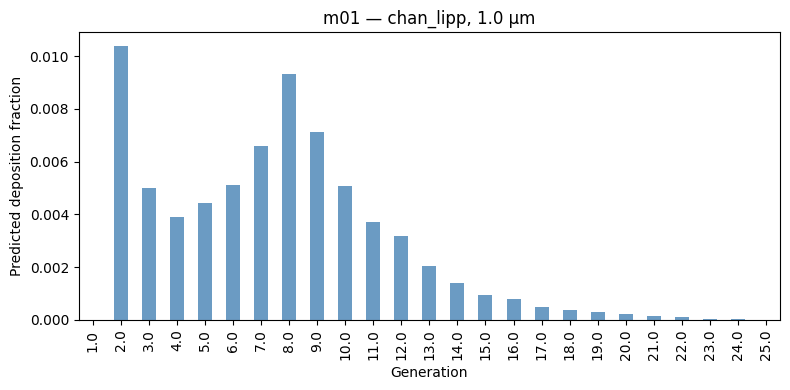

In [5]:
# Plot predicted deposition by airway generation
dep_by_gen = tree.groupby("generation")["p_deposition_aggreg"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
dep_by_gen.plot(kind="bar", ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Generation")
ax.set_ylabel("Predicted deposition fraction")
ax.set_title(f"{mouse_id} — {IMPACTION_MODEL}, {PARTICLE_SIZE*1e6:.1f} µm")
plt.tight_layout()
plt.show()


## 3. Compare impaction models

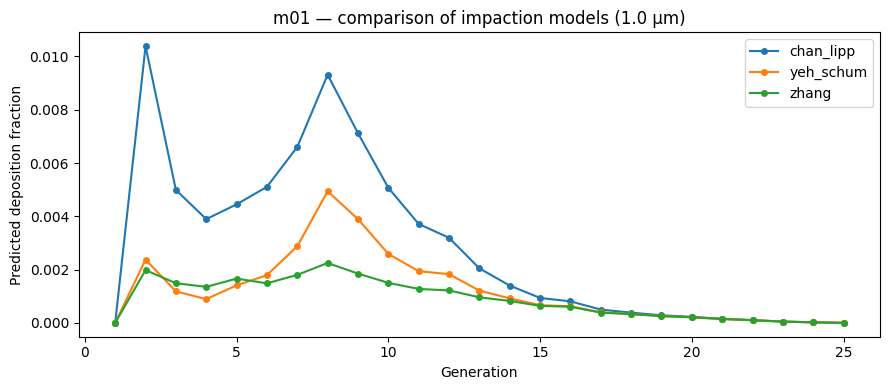

In [6]:
impaction_models = ["chan_lipp", "yeh_schum", "zhang"]
dep_results = {}

for model in impaction_models:
    tree_m = data[mouse_id]["tree_table"].copy()
    add_child(tree_m)
    root_label = tree_m[tree_m["parent"] == 0]["label"].values[0]
    tree_m.loc[tree_m["label"] == root_label, "Q"] = Q_INTAKE
    propagate_flow(tree_m, root_label)
    compute_generation(tree_m)
    compute_probabilities(tree_m, particle_diameter=PARTICLE_SIZE, model=model)
    tree_m.loc[tree_m["label"] == root_label, "p_escape_aggreg"] = 1.0
    tree_m.loc[tree_m["label"] == root_label, "p_deposition_aggreg"] = 0.0
    propagate_probabilities(tree_m, root_label)
    dep_results[model] = tree_m.groupby("generation")["p_deposition_aggreg"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
for model, dep in dep_results.items():
    dep.plot(ax=ax, marker="o", markersize=4, label=model)
ax.set_xlabel("Generation")
ax.set_ylabel("Predicted deposition fraction")
ax.set_title(f"{mouse_id} — comparison of impaction models ({PARTICLE_SIZE*1e6:.1f} µm)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Aggregate results across multiple mice

In [7]:
# Load all mice and aggregate predicted deposition by generation
# This may take a few minutes depending on the number of mice

all_data = load_trees(DATA_PATH, Q_intake=Q_INTAKE)
mice_ids = list(all_data.keys())
print(f"Loaded {len(mice_ids)} mice: {mice_ids}")

Loaded 34 mice: ['m30', 'm02', 'm33', 'm13', 'm20', 'm06', 'm12', 'm34', 'm23', 'm16', 'm21', 'm25', 'm09', 'm15', 'm26', 'm24', 'm01', 'm07', 'm18', 'm22', 'm31', 'm32', 'm08', 'm17', 'm10', 'm27', 'm03', 'm19', 'm29', 'm28', 'm04', 'm11', 'm05', 'm14']


100%|██████████| 34/34 [04:20<00:00,  7.67s/it]


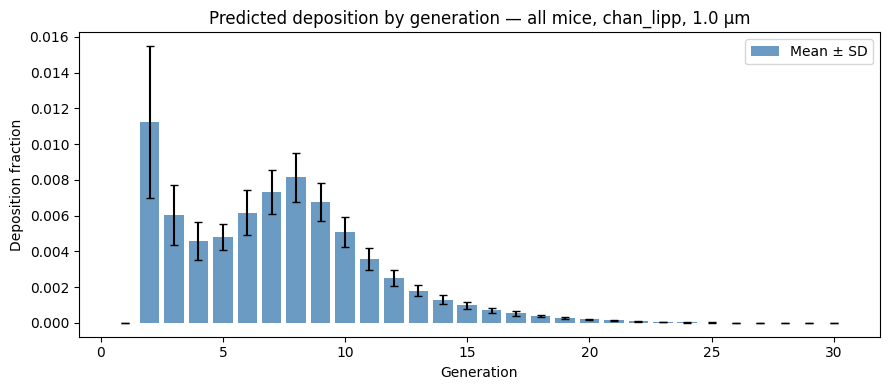

In [8]:
from tqdm import tqdm

dep_per_mouse = []

for mid in tqdm(mice_ids):
    tree_m = all_data[mid]["tree_table"].copy()
    add_child(tree_m)
    root = tree_m[tree_m["parent"] == 0]["label"].values[0]
    tree_m.loc[tree_m["label"] == root, "Q"] = Q_INTAKE
    propagate_flow(tree_m, root)
    compute_generation(tree_m)
    compute_probabilities(tree_m, particle_diameter=PARTICLE_SIZE, model="chan_lipp")
    tree_m.loc[tree_m["label"] == root, "p_escape_aggreg"] = 1.0
    tree_m.loc[tree_m["label"] == root, "p_deposition_aggreg"] = 0.0
    propagate_probabilities(tree_m, root)
    gen_dep = tree_m.groupby("generation")["p_deposition_aggreg"].sum().rename(mid)
    dep_per_mouse.append(gen_dep)

dep_df = pd.DataFrame(dep_per_mouse).T.fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
mean_dep = dep_df.mean(axis=1)
std_dep = dep_df.std(axis=1)
ax.bar(mean_dep.index, mean_dep.values, yerr=std_dep.values, capsize=3,
        color="steelblue", alpha=0.8, label="Mean ± SD")
ax.set_xlabel("Generation")
ax.set_ylabel("Deposition fraction")
ax.set_title(f"Predicted deposition by generation — all mice, chan_lipp, {PARTICLE_SIZE*1e6:.1f} µm")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Compare with morphometric references

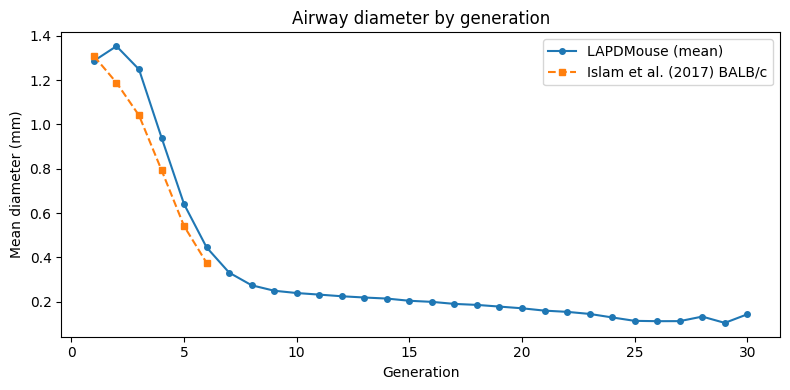

In [9]:
import sys
sys.path.insert(0, str(Path("../data")))
from morphometry_references import ISLAM_BALBC_2017

# Compare average airway diameter per generation between lapdMouse data and reference
diameter_by_gen = {mid: all_data[mid]["tree_table"].copy() for mid in mice_ids}
for df in diameter_by_gen.values():
    compute_generation(df)
mean_diam = pd.concat([
    df.assign(mouse=mid) for mid, df in diameter_by_gen.items()
]).groupby("generation")["radius"].mean() * 2 * 1000  # convert m -> mm

fig, ax = plt.subplots(figsize=(8, 4))
mean_diam.plot(ax=ax, marker="o", markersize=4, label="LAPDMouse (mean)")
ax.plot(ISLAM_BALBC_2017["generation"], ISLAM_BALBC_2017["diameter_mm"],
        marker="s", markersize=4, linestyle="--", label="Islam et al. (2017) BALB/c")
ax.set_xlabel("Generation")
ax.set_ylabel("Mean diameter (mm)")
ax.set_title("Airway diameter by generation")
ax.legend()
plt.tight_layout()
plt.show()


## Next steps

To run a full comparison of all impaction models across all mice and particle sizes, use the CLI script from the main folder :

```bash
python scripts/compare_impaction_models.py \
    --data_path /path/to/lapdmouse/data \
    --results_path results \
    --particle_sizes 5e-7 1e-6 2e-6 \
    --impaction_models chan_lipp yeh_schum zhang \
    --use_mouse_ventilation
```
